# Dipole Antenna Array

In this example we apply array factor approximation to obtain radiation characteristics of antenna arrays.

In [1]:
# Tidy3d import
import matplotlib.pyplot as plt

# External modules needed for this notebook
import numpy as np
import tidy3d as td

# Tidy3d plugin import
import tidy3d.plugins.smatrix as smatrix
from tidy3d import web
from tidy3d.plugins.microwave import (
    ChebWindow,
    HammingWindow,
    RadialTaper,
    RectangularAntennaArrayCalculator,
    RectangularTaper,
    TaylorWindow,
)

td.config.logging_level = "ERROR"

Define the operating frequency range and frequency points for recording simulation data.

In [ ]:
# Scaling used for millimeters
mm = 1e3

# Frequency range
freq_start = 5e9
freq_stop = 15e9

freq0 = (freq_start + freq_stop) / 2  # Central frequency
freqs_target = np.linspace(freq_start, freq_stop, 5)
fwidth = freq_stop - freq_start  # Bandwidth

# Wavelength of central frequency in Vacuum
wavelength0 = td.C_0 / freq0

# Frequency sweep for S-parameters
freqs = np.linspace(freq_start, freq_stop, 201)

## Single Antenna Simulation

Define dimensions of the dipole antenna.

In [3]:
# Dipole parameters
dipole_length = 0.47 * wavelength0
dipole_radius = wavelength0 / 150

Compute auxiliary parameters.

In [4]:
dipole_width = dipole_radius * 4
dipole_gap = dipole_width
arm_length = 0.5 * (dipole_length - dipole_gap)
arm_center = 0.5 * arm_length + 0.5 * dipole_gap

pml_buffer = 0.25 * wavelength0

sim_x = dipole_length + 2 * pml_buffer
sim_y = dipole_width + 2 * pml_buffer
sim_z = dipole_width + 2 * pml_buffer

Define materials.

In [5]:
# Material present
air = td.Medium()
eps_r = 2.2
sub_medium = td.Medium(permittivity=eps_r)
PEC = td.PEC2D  # Thickness-free PEC medium

Create structures representing dipole arms.

In [6]:
arm_a = td.Structure(
    geometry=td.Box(center=[-arm_center, 0, 0], size=[arm_length, dipole_width, 0]),
    medium=PEC,
)

arm_b = td.Structure(
    geometry=td.Box(center=[arm_center, 0, 0], size=[arm_length, dipole_width, 0]),
    medium=PEC,
)

Define monitors.

In [ ]:
# Define observation parameters used for projection monitors
theta = np.linspace(0, np.pi, 101)
phi = np.linspace(0, 2 * np.pi, 101)

# Field monitor to view the electromagnetic fields in the dipole plane
monitor_field = td.FieldMonitor(
    center=(0, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="field",
)

# Angular projection monitor to view radiation intensity
monitor_projection = td.FieldProjectionAngleMonitor(
    center=[0, 0, 0],
    size=(
        dipole_length + pml_buffer,
        dipole_width + pml_buffer,
        dipole_width + pml_buffer,
    ),  # We introduce a monitor box to enclose the whole structure of interest
    freqs=freqs_target,
    name="radiation",
    phi=list(phi),
    theta=list(theta),
    far_field_approx=False,
)

# We define a ``DirectivityMonitor`` to obtain radiation characteristics such as directivity, axial ratio and polarized far fields.
monitor_directivity = td.DirectivityMonitor(
    center=[0, 0, 0],
    size=monitor_projection.size,
    freqs=freqs_target,
    name="directivity",
    phi=list(phi),
    theta=list(theta),
    far_field_approx=False,
)

Create simulation specification for the antenna.

In [8]:
# Create the simulation object
sim = td.Simulation(
    center=(0 * mm, 0 * mm, 0 * mm),
    medium=td.Medium(permittivity=4),
    size=[sim_x, sim_y, sim_z],
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=20,  # The largest cell size is set to 20 cells per smallest wavelength.
        wavelength=td.C_0 / freq_stop,  # Smallest wavelength to resolve
    ),
    structures=[arm_a, arm_b],
    monitors=[monitor_projection, monitor_field, monitor_directivity],
    run_time=100 * (wavelength0 / td.C_0),
    plot_length_units="mm",  # This option will make plots default to units of millimeters.
)

Simulation visualization.

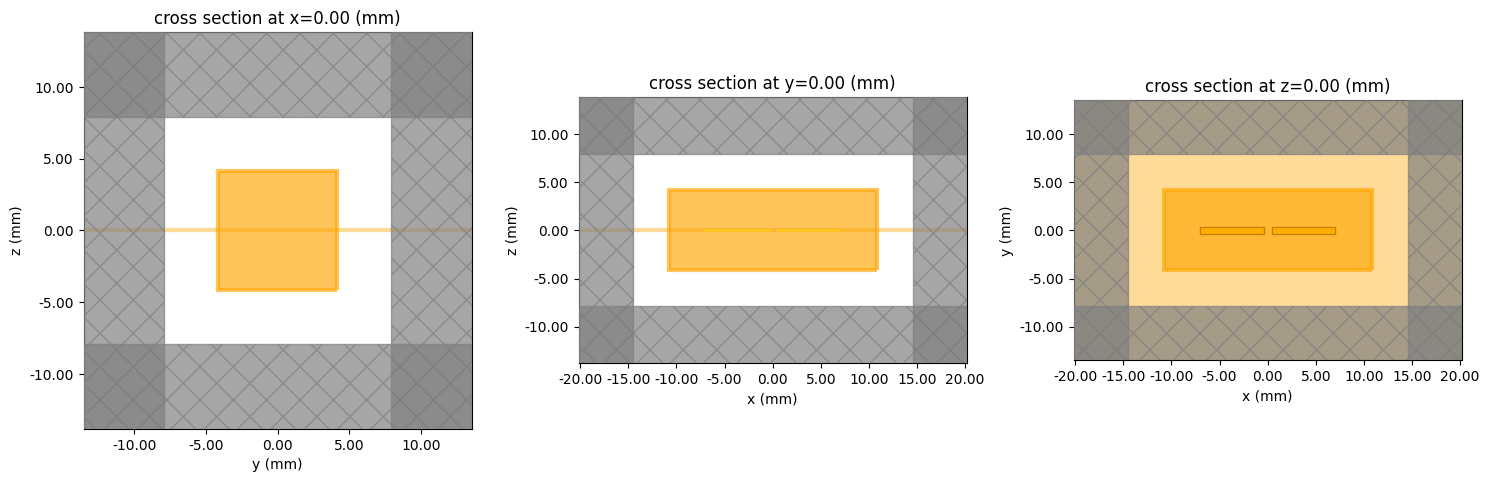

In [9]:
_, ax = plt.subplots(1, 3, figsize=(15, 5))
sim.plot(x=0, ax=ax[0])
sim.plot(y=0, ax=ax[1])
sim.plot(z=0, ax=ax[2])

plt.tight_layout()
plt.show()

Put a lumped port between dipole arms.

In [10]:
# Define the port impedance
port_impedance = 50

# Setup a LumpedPort for the TerminalComponentModeler
port = smatrix.LumpedPort(
    center=[0, 0, 0],
    size=[dipole_gap, dipole_width, 0],
    voltage_axis=0,
    name="lumped_port",
    impedance=port_impedance,
)

# We integrate the base simulation with the LumpedPort using the TerminalComponentModeler.
modeler = smatrix.TerminalComponentModeler(
    simulation=sim,
    ports=[port],
    freqs=freqs,
    remove_dc_component=False,  # Include DC component for more accuracy at low frequencies
)

sim_unit = list(modeler.sim_dict.values())[0]

Mesh visualization.

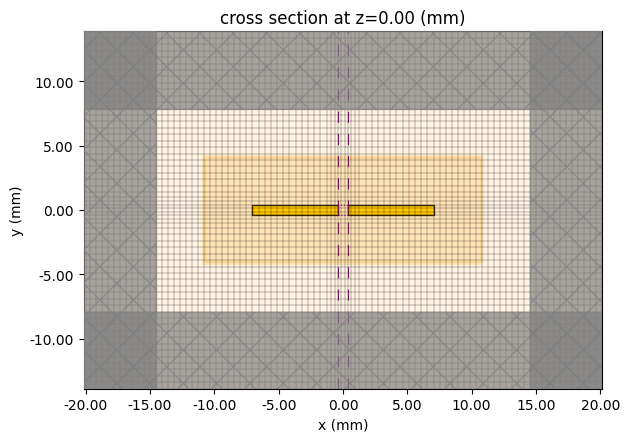

In [11]:
ax = sim_unit.plot(z=0, monitor_alpha=0.1)
sim_unit.plot_grid(z=0, ax=ax, monitor_alpha=0)
plt.show()

Run simulation to obtain radiation parameters of a single antenna.

In [12]:
sim_unit_data = web.run(sim_unit, task_name="single_dipole", path="data/dipole_antenna.hdf5")

23:00:47 EDT Created task 'single_dipole' with resource_id                      
             'fdve-9fb91ee1-c853-4142-807c-5091b92842d4' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=687074;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9fb91ee1-c853-4142-807c-5091b92842d4\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=267793;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9fb91ee1-c853-4142-807c-5091b92842d4\taskId]8;;\]8;id=687074;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9fb91ee1-c853-4142-807c-5091b92842d4\=]8;;\]8;id=122072;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9fb91ee1-c853-4142-807c-5091b92842d4\fdve]8;;\]8;id=687074;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9fb91ee1-c853-4142-807c-5091b92842d4\-9fb91ee1-c85]8;;\
             ]8;id=687074;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9fb91ee1-c853-4142-807c-5091b92842d4\3-4142-807c-5091b92842d4']8;;\.

             Task folder: ]8;id=690787;https://tidy3d.simulation.cloud/folders/folder-f7b925a9-b2c3-4519-8f36-17122860e556\'default']8;;\.

Output()

23:00:57 EDT Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

23:00:58 EDT status = success

Output()

23:01:00 EDT loading simulation from data/dipole_antenna.hdf5

## Antenna Array Calculations

Now we can use Tidy3D convenience functions to approximate radiation characteristics of a phased antenna array based on the results of a single antenna simulation.

Let us define parameters of the array of interest.

In [13]:
# phase array parameters
array_size = [3, 4, 1]
spacings = [0.5 * wavelength0, 0.5 * wavelength0, 0.5 * wavelength0]
phase_shifts = [0, 0, 0]

In [ ]:
# set up RectangularAntennaArrayCalculator
array_calc = RectangularAntennaArrayCalculator(
    array_size=array_size,
    spacings=spacings,
    phase_shifts=phase_shifts,
)

Now we use function `simulation_data_from_array_factor` that converts simulation data from a single antenna into simulation data of a phase array based on pattern multiplication approximation. It only preserves field projection monitors as indicated by warnings.

In [15]:
sim_array_data_from_af = array_calc.simulation_data_from_array_factor(
    antenna_data=sim_unit_data,
)

Note that this function automatically replaces simulation specification as well. That is, we can use `.simulation` field of the resulting simulation data object to visualize and run simulation for the antenna array.

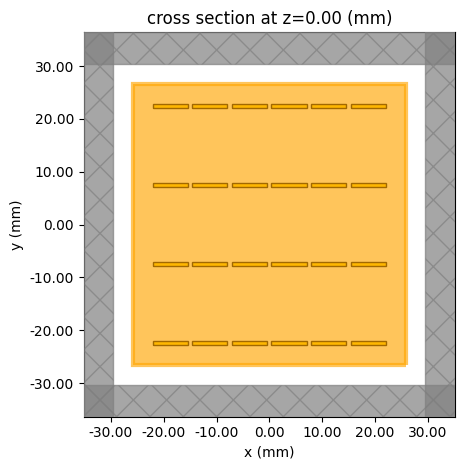

In [16]:
# generate simulation for the antenna array from simulation array data
sim_array = sim_array_data_from_af.simulation

# visualize simulation for the antenna array
ax = sim_array.plot(z=0)
plt.show()

Run a direct simulation for the antenna array. The results would be used as a ground truth in validation of antenna array radiation pattern. 

In [17]:
sim_array_data_direct = web.run(
    sim_array,
    task_name="rectangle_array_of_dipoles",
    path="data/dipole_array_antenna.hdf5",
    verbose=False,
)

Compare approximated and direct simulation results.

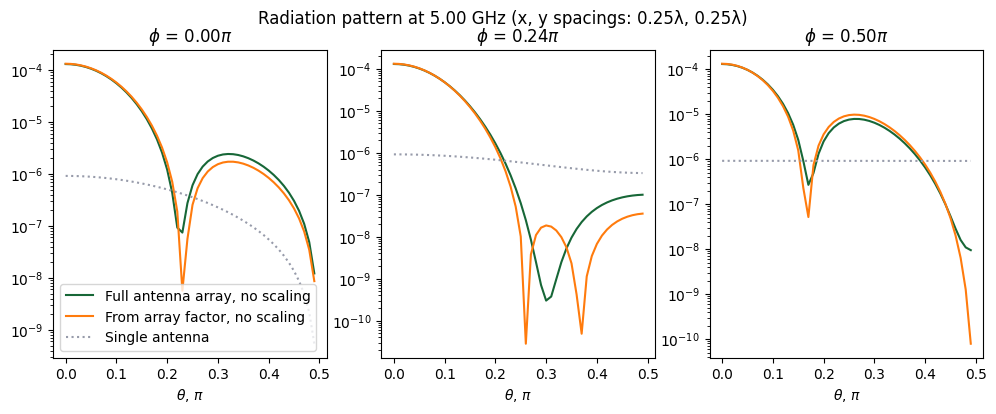

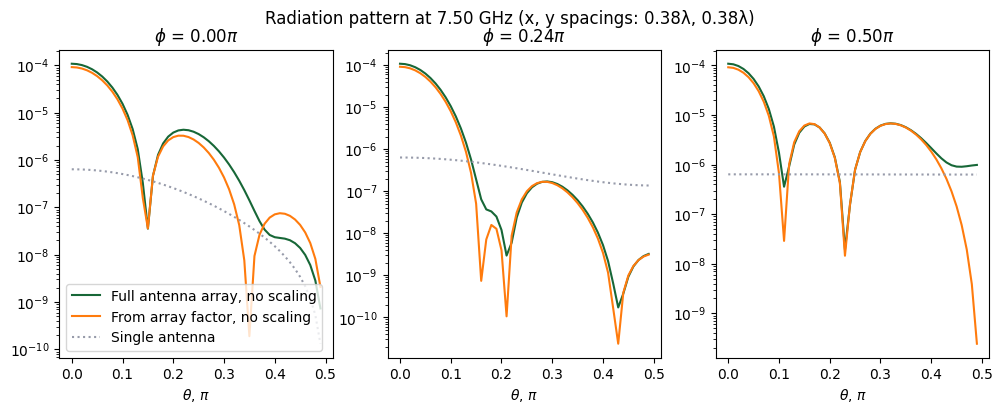

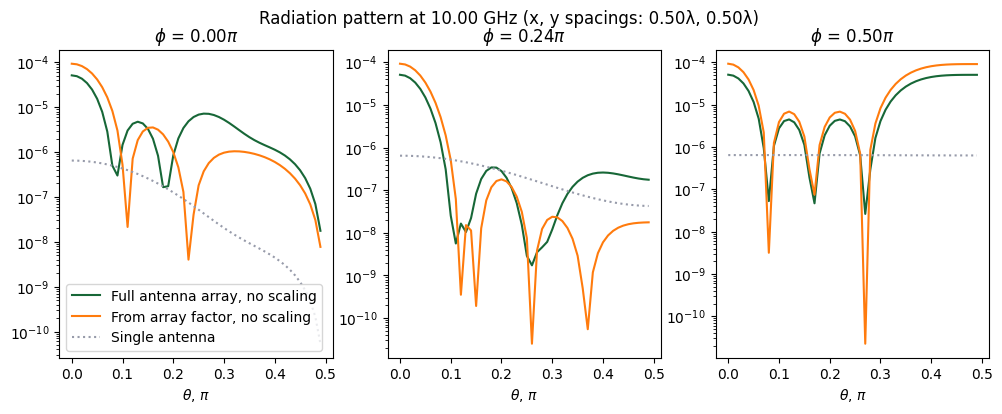

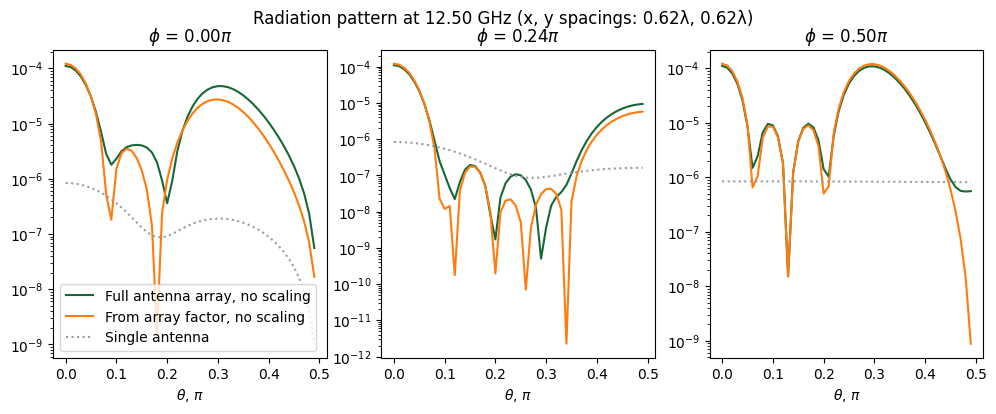

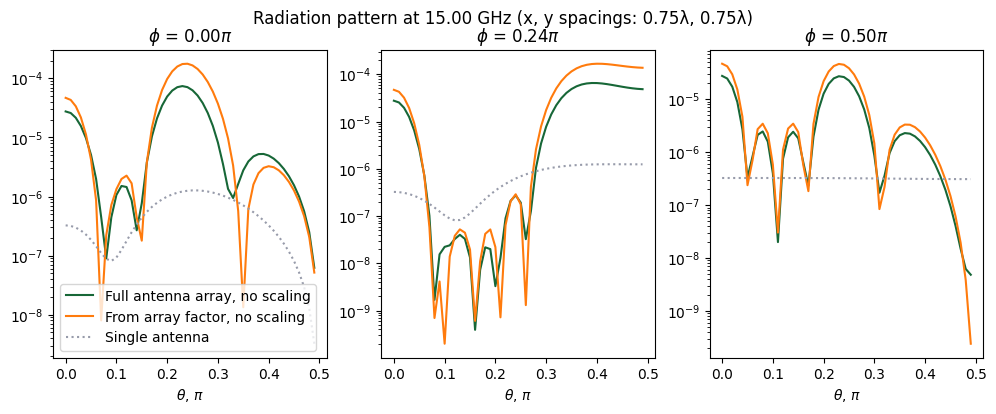

In [25]:
phi_plot_inds = [0, 12, 25]
num_phi_plots = len(phi_plot_inds)

for freq_plot in freqs_target:
    # create a new pyplot figure and
    fig, axes = plt.subplots(1, num_phi_plots, figsize=(num_phi_plots * 4, 4))

    # compute current wavelength
    wavelength = td.C_0 / freq_plot

    # set title
    fig.suptitle(
        f"Radiation pattern at {freq_plot / 1e9:.2f} GHz "
        f"(x, y spacings: {spacings[0] / wavelength:.2f}λ, {spacings[1] / wavelength:.2f}λ)",
    )

    for ind, ax in enumerate(axes):
        ax.set_title(rf"$\phi$ = {phi[phi_plot_inds[ind]] / np.pi:.2f}$\pi$")
        ax.set_xlabel(r"$\theta$, $\pi$")

    def plot_data(data, label, style, axes=axes, theta=theta, phi_plot_inds=phi_plot_inds):
        for ind, ax in enumerate(axes):
            ax.semilogy(
                theta[0:50] / np.pi, np.abs(data[0:50, phi_plot_inds[ind]]), style, label=label
            )

    plot_data(
        sim_array_data_direct["radiation"].power.sel(f=freq_plot).data[0],
        "Full antenna array, no scaling",
        "-",
    )
    plot_data(
        sim_array_data_from_af["radiation"].power.sel(f=freq_plot).data[0],
        "From array factor, no scaling",
        "-",
    )
    plot_data(sim_unit_data["radiation"].power.sel(f=freq_plot).data[0], "Single antenna", ":")

    # add legends
    axes[0].legend()

    plt.show()

## Tapering

**Tapering** is a commonly used method in antenna arrays to adjust amplitude of signals across antenna elements to suppress side lobes of the radiation pattern at a cost of widening the main lobe. Taper method lies in applying weighting functions (windows) to adjust antenna array elements' amplitudes  

In [19]:
# choose window for taper
win_x = ChebWindow(attenuation=45)
win_y = TaylorWindow(sll=35, nbar=4)

# set up a RectangularTaper with the same taper applied along all axes
taper_isotropic = RectangularTaper.from_isotropic_window(window=win_y)

# alternatively, in ``RectangularTaper`` one can specify distinct tapers along some/all directions.
# Uniform amplitudes (with weight of 1.0) are used along missing window directions
taper_xy = RectangularTaper(window_x=win_x, window_y=win_y)

# Finally, one may also want to use a ``CircularTaper``.
# This type of taper requires specification of only one window and currently supports only ``TaylorWindow``
taper_radial = RadialTaper(window=win_y)

``RectangularAntennaArrayCalculator``  supports amplitude scaling via ``amp_multipliers`` or ``taper`` fields. If a valid ``taper`` is specified, it overrides user-specified ``amp_multipliers`` with amplitudes drawn from the taper kernel provided.

In [ ]:
# specify RectangularAntennaArrayCalculator with isotropic taper
array_calc_taper = RectangularAntennaArrayCalculator(
    array_size=array_size, spacings=spacings, phase_shifts=phase_shifts, taper=taper_isotropic
)

# alternatively, one get the same result by extracting weights from taper and passing them to RectangularAntennaArrayCalculator directly
amp_x, amp_y, amp_z = taper_isotropic.amp_multipliers(array_size=array_size)
array_calc_amp_mult = RectangularAntennaArrayCalculator(
    array_size=array_size,
    spacings=spacings,
    phase_shifts=phase_shifts,
    amp_multipliers=[amp_x, amp_y, amp_z],
)

Convert simulation data from a single antenna into simulation data of a phase array based on pattern multiplication approximation. 

In [21]:
sim_array_data_from_af_taper = array_calc_taper.simulation_data_from_array_factor(
    antenna_data=sim_unit_data
)

sim_array_data_from_af_amp = array_calc_amp_mult.simulation_data_from_array_factor(
    antenna_data=sim_unit_data,
)

In [22]:
# extract simulations for antenna arrays with the taper and amplitude scaling, respectively
sim_tapered_array = sim_array_data_from_af_taper.simulation
sim_array_amp = sim_array_data_from_af_amp.simulation

# run simulations for the antenna arrays
sim_array_data_taper_direct = web.run(
    sim_tapered_array,
    task_name="tapered_rectangle_array_of_dipoles",
    path="data/dipole_array.hdf5",
    verbose=False,
)
sim_array_data_amp_direct = web.run(
    sim_array_amp,
    task_name="rectangle_array_of_dipoles_amps",
    path="data/dipole_array_amps.hdf5",
    verbose=False,
)

Compare direct and approximate results for antenna arrays with taper. 

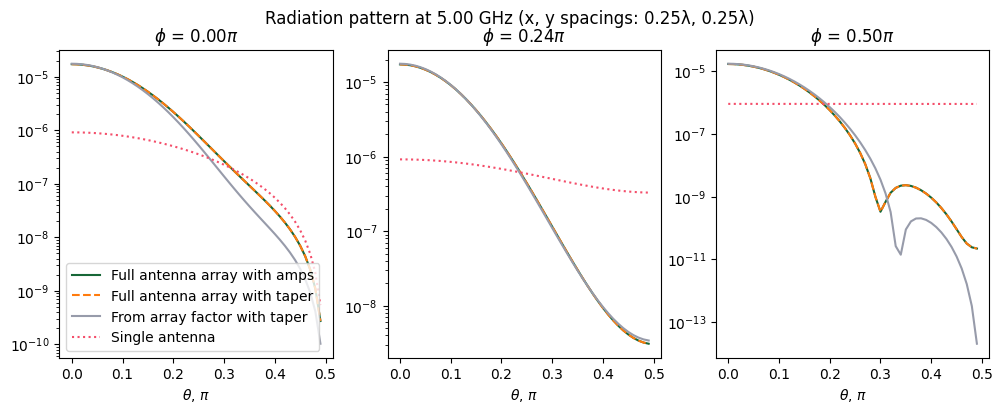

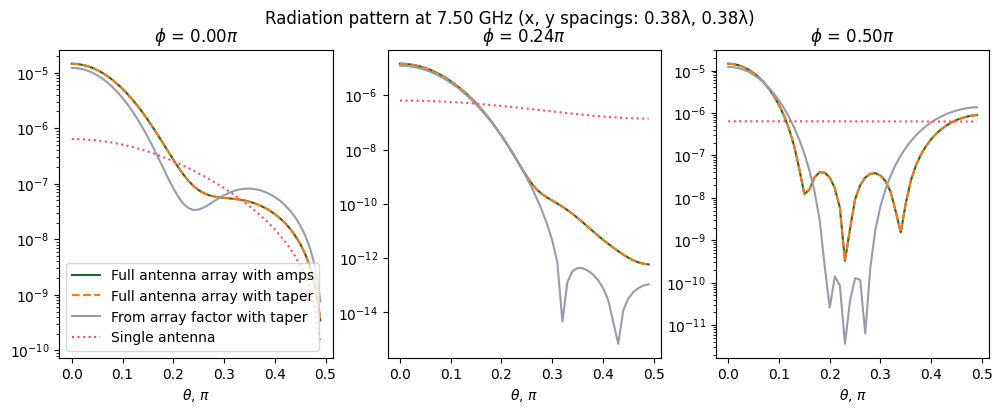

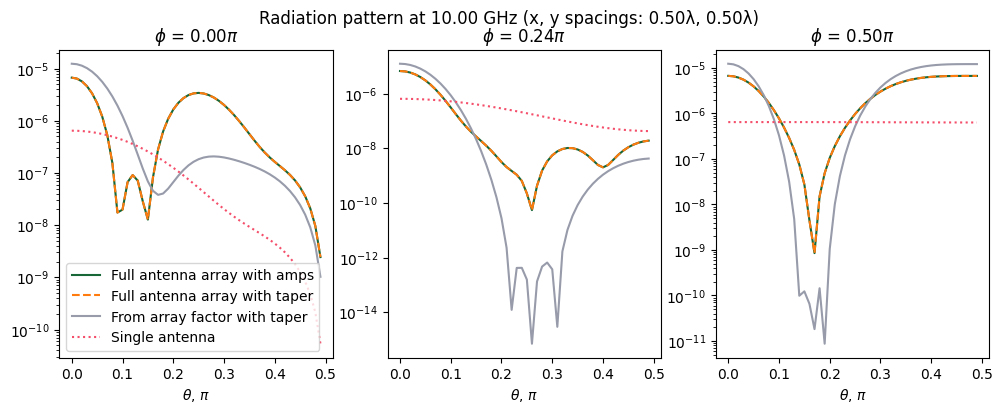

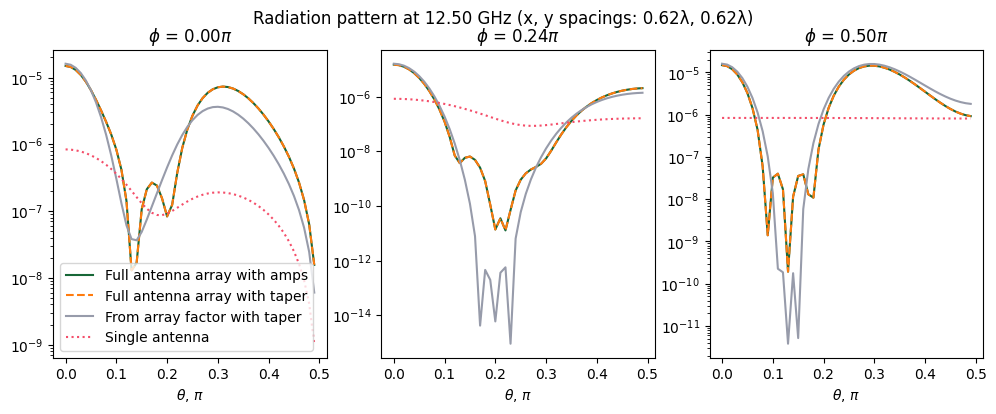

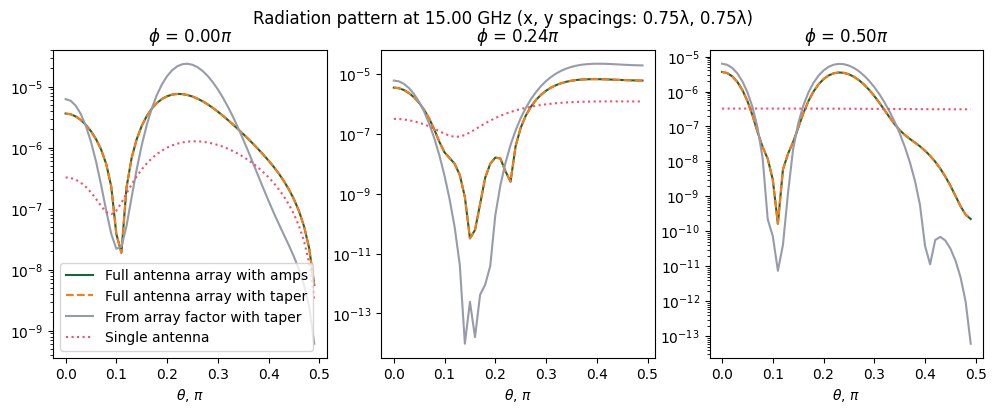

In [24]:
phi_plot_inds = [0, 12, 25]
num_phi_plots = len(phi_plot_inds)

for freq_plot in freqs_target:
    # create a new pyplot figure and
    fig, axes = plt.subplots(1, num_phi_plots, figsize=(num_phi_plots * 4, 4))

    # compute current wavelength
    wavelength = td.C_0 / freq_plot

    # set title
    fig.suptitle(
        f"Radiation pattern at {freq_plot / 1e9:.2f} GHz "
        f"(x, y spacings: {spacings[0] / wavelength:.2f}λ, {spacings[1] / wavelength:.2f}λ)",
    )

    for ind, ax in enumerate(axes):
        ax.set_title(rf"$\phi$ = {phi[phi_plot_inds[ind]] / np.pi:.2f}$\pi$")
        ax.set_xlabel(r"$\theta$, $\pi$")

    def plot_data(data, label, style, axes=axes, theta=theta, phi_plot_inds=phi_plot_inds):
        for ind, ax in enumerate(axes):
            ax.semilogy(
                theta[0:50] / np.pi, np.abs(data[0:50, phi_plot_inds[ind]]), style, label=label
            )

    plot_data(
        sim_array_data_amp_direct["radiation"].power.sel(f=freq_plot).data[0],
        "Full antenna array with amps",
        "-",
    )
    plot_data(
        sim_array_data_taper_direct["radiation"].power.sel(f=freq_plot).data[0],
        "Full antenna array with taper",
        "--",
    )
    plot_data(
        sim_array_data_from_af_taper["radiation"].power.sel(f=freq_plot).data[0],
        "From array factor with taper",
        "-",
    )
    plot_data(sim_unit_data["radiation"].power.sel(f=freq_plot).data[0], "Single antenna", ":")

    # add legends
    axes[0].legend()

    plt.show()